# Unmixing the Music
## Sparse, Low-Rank, and Deep: A Compressed-Sensing Approach to Music Source Separation

**ENGS 109 - High-Dimensional Sensing and Learning - Final Project**
**Taka Khoo, Thayer School of Engineering, Dartmouth College**

---

This notebook reproduces the entire project end to end. Given a finished song, we
recover its two hidden tracks, the **vocals** and the **accompaniment**, four
different ways, and show that all four are the same idea: recover a *structured*
(sparse or low-rank) version of the spectrogram.

The whole course lives in one equation, the underdetermined system

$$ \mathbf{y} = \mathbf{A}\mathbf{x}, \qquad \mathbf{x}\ \text{sparse}. $$

The classical half of the subject **fixes the dictionary $\mathbf{A}$ and recovers
the code**; dictionary learning, K-SVD, and NMF instead **learn $\mathbf{A}$ from
data**; and a deep sparse coding network sits at the learned end of the same
continuum, an unrolled solver that is, in a precise sense, a learned autoencoder.
A sparse vector and a low-rank matrix are two sides of the same coin: rank is the
$\ell_0$ norm of the singular spectrum and the nuclear norm is its $\ell_1$
relaxation.

**What this notebook does, cell by cell:**
1. Set up and load one MUSDB18 song.
2. Look at the data: the spectrogram, where sparsity and low rank live.
3. Method A: Robust PCA (low-rank + sparse), training-free.
4. Method B: supervised NMF (learned per-source dictionaries).
5. Method C: K-SVD + sparse-representation classification.
6. Method D: the deep sparse coding network (unrolled, learned end to end).
7. The full comparison on 25 test tracks, with the headline table and figure.
8. Ablations: what each knob does.
9. The honest negative result on dictionary coherence.

Every separation cell prints a scale-invariant SDR (SI-SDR, in dB, higher is
better) and embeds a playable audio widget so you can hear the result.

## 0. Setup

We add `src/` to the path so we can import the project's `separation` package,
then load the pre-trained dictionaries and network so the notebook runs in a
couple of minutes. The MUSDB18 7-second sample set (144 free tracks) is
auto-downloaded on first run.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

REPO = Path.cwd()
sys.path.insert(0, str(REPO / "src"))

import numpy as np
import matplotlib.pyplot as plt
import librosa, librosa.display
from IPython.display import Audio, display

from separation.features import SR, stft, istft, magphase, to_db
from separation.io import get_musdb, track_to_mono
from separation.metrics import si_sdr
from separation import stage_a_rpca, stage_b_nmf, stage_c_ksvd, baselines

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
print("imports OK, sample rate =", SR, "Hz")

imports OK, sample rate = 22050 Hz


In [2]:
# Download the MUSDB18 7-second sample set if it is not already present.
DATA = REPO / "data" / "musdb18_sample"
if not (DATA / "test").exists():
    import musdb
    musdb.DB(download=True, root=str(DATA))
mus = get_musdb(subsets="test")
print(f"{len(mus)} test tracks available")

50 test tracks available


## 1. The data: a song is a picture of sound

The **short-time Fourier transform (STFT)** turns audio into an image: time on the
x-axis, pitch on the y-axis, brightness = energy. We pick one test song and look at
the mixture next to its true vocal and accompaniment stems (which MUSDB18 provides).

Look at the structure you can *see*:
- **Vocals are sparse**: a few bright horizontal harmonic lines per instant.
- **Accompaniment is low-rank**: a denser field built from a few repeating patterns.

Those two structures are exactly what compressed sensing recovers.

Track: Al James - Schoolboy Facination


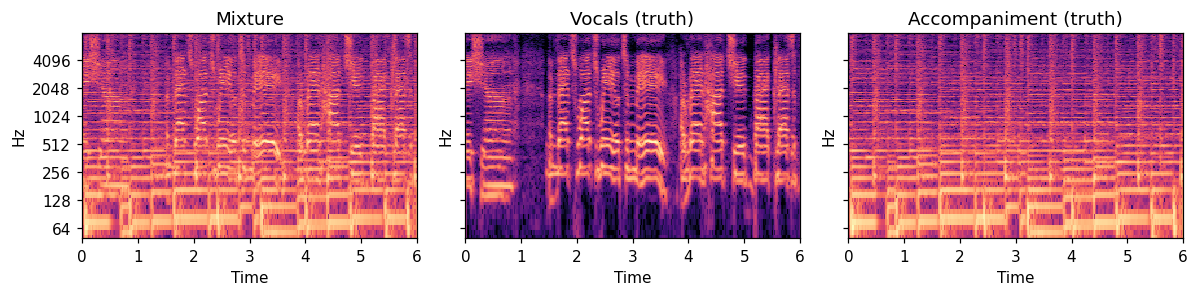

Listen to the mixture we will try to un-mix:


In [3]:
# Pick a representative track (fall back to the first vocal track).
def pick_track(hint="Al James"):
    for tr in mus:
        if hint.lower() in tr.name.lower():
            return tr
    return list(mus)[0]

track = pick_track()
stems = track_to_mono(track)
n = 6 * SR                          # use a 6-second clip
y    = stems["mix"][:n]
voc  = stems["vocals"][:n]
acc  = stems["accompaniment"][:n]
print("Track:", track.name)

fig, ax = plt.subplots(1, 3, figsize=(11, 2.8), sharey=True)
for a, sig, t in zip(ax, [y, voc, acc], ["Mixture", "Vocals (truth)", "Accompaniment (truth)"]):
    librosa.display.specshow(to_db(np.abs(stft(sig))), sr=SR, hop_length=512,
                             x_axis="time", y_axis="log", ax=a, cmap="magma")
    a.set_title(t); a.set_ylim(40, 8000)
plt.tight_layout(); plt.show()
print("Listen to the mixture we will try to un-mix:")
display(Audio(y, rate=SR))

## 2. Method A: Robust PCA (low-rank + sparse)

The first method needs **no training**. We split the magnitude spectrogram
$\mathbf{M}$ into a **low-rank** part $\mathbf{X}$ (the repeating accompaniment) and
a **sparse** part $\mathbf{E}$ (the voice) by principal component pursuit:

$$ \min_{\mathbf{X},\mathbf{E}}\ \|\mathbf{X}\|_* + \lambda\|\mathbf{E}\|_1
   \quad\text{s.t.}\quad \mathbf{X}+\mathbf{E}=\mathbf{M},\qquad
   \lambda = 1/\sqrt{\max(F,T)}. $$

$\|\mathbf{X}\|_*$ is the nuclear norm (the $\ell_1$ of the singular values, our
stand-in for low rank) and $\|\mathbf{E}\|_1$ is the stand-in for sparse. It is the
same trick that pulls a moving person out of a static surveillance background.

In [4]:
res_A = stage_a_rpca.separate(y, max_iter=80)
print(f"RPCA converged: rank {res_A['info']['rank']}, {res_A['info']['iters']} iters")
print(f"  vocals  SI-SDR: {si_sdr(voc, res_A['vocals']):+.2f} dB")
print(f"  accomp. SI-SDR: {si_sdr(acc, res_A['accompaniment']):+.2f} dB")
display(Audio(res_A["accompaniment"], rate=SR))   # the low-rank accompaniment

RPCA converged: rank 168, 38 iters
  vocals  SI-SDR: +0.78 dB
  accomp. SI-SDR: -0.01 dB


## 3. Method B: supervised NMF (learned dictionaries)

Now we **learn** something. Before testing, we learn a small nonnegative
**dictionary** of spectral templates (*atoms*) for each source from isolated stems,
$\mathbf{M}_c \approx \mathbf{D}_c \mathbf{H}_c$, using Lee-Seung multiplicative
updates. At test time we hold the dictionaries fixed and only solve for the
activations, then read off how much of each source is present. (We load the
dictionaries trained earlier.)

This is the smoothie trick: learn the pure flavor of each fruit, then estimate how
much of each is in a new smoothie.

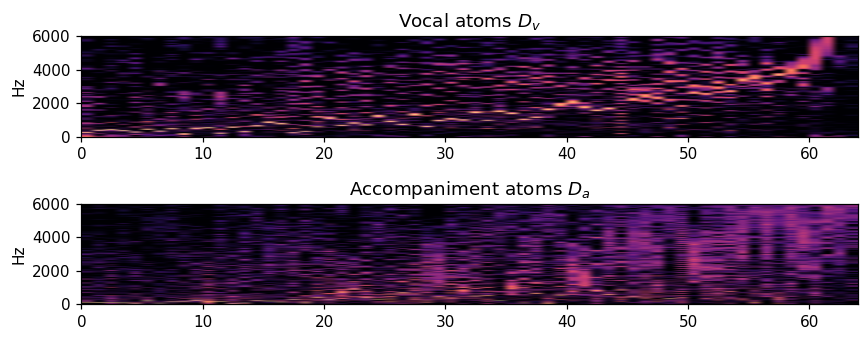

NMF  vocals SI-SDR: +3.09 dB   accomp. SI-SDR: +3.11 dB


In [5]:
nmf = np.load(REPO / "experiments" / "dictionaries" / "nmf.npz")
Dv_nmf, Da_nmf = nmf["Dv"], nmf["Da"]

# Show a few learned atoms (sorted by pitch) for each source.
freqs = librosa.fft_frequencies(sr=SR, n_fft=2048)
def sort_atoms(D):
    cen = (freqs[:, None] * D).sum(0) / (D.sum(0) + 1e-9)
    return D[:, np.argsort(cen)]
fig, ax = plt.subplots(2, 1, figsize=(8, 3.2))
for a, D, t in zip(ax, [sort_atoms(Dv_nmf), sort_atoms(Da_nmf)],
                   ["Vocal atoms $D_v$", "Accompaniment atoms $D_a$"]):
    a.imshow(librosa.amplitude_to_db(D + 1e-6, ref=np.max), aspect="auto",
             origin="lower", cmap="magma", extent=[0, D.shape[1], 0, freqs[-1]])
    a.set_ylim(0, 6000); a.set_title(t); a.set_ylabel("Hz")
plt.tight_layout(); plt.show()

res_B = stage_b_nmf.separate(y, Dv_nmf, Da_nmf, beta="kl")
print(f"NMF  vocals SI-SDR: {si_sdr(voc, res_B['vocals']):+.2f} dB   "
      f"accomp. SI-SDR: {si_sdr(acc, res_B['accompaniment']):+.2f} dB")
display(Audio(res_B["vocals"], rate=SR))

## 4. Method C: K-SVD + sparse-representation classification

K-SVD learns a sharper, **overcomplete** dictionary that can sparsely spell out each
source. At test time we sparse-code each mixture frame on the combined dictionary
$[\mathbf{D}_v \mid \mathbf{D}_a]$ with OMP and assign energy to whichever source
spells the frame best (the SRC residual rule). Think of giving each singer their own
alphabet of sound-letters.

In [6]:
ksvd = np.load(REPO / "experiments" / "dictionaries" / "ksvd.npz")
Dv_ksvd, Da_ksvd = ksvd["Dv"], ksvd["Da"]
res_C = stage_c_ksvd.separate(y, Dv_ksvd, Da_ksvd, n_nonzero=10)
print(f"K-SVD  vocals SI-SDR: {si_sdr(voc, res_C['vocals']):+.2f} dB   "
      f"accomp. SI-SDR: {si_sdr(acc, res_C['accompaniment']):+.2f} dB")
display(Audio(res_C["vocals"], rate=SR))

K-SVD  vocals SI-SDR: +3.49 dB   accomp. SI-SDR: +3.46 dB


## 5. Method D: the deep sparse coding network (the new method)

A neural network *is* a sparse-recovery solver with its iterations **unrolled** into
layers. We keep that structure but **learn** the dictionaries by backpropagation.
Each module is an expand-then-reduce hourglass: a *fat* dictionary lifts the frame
to an over-complete sparse code, a *tall* dictionary compresses it. We unroll a
non-negative FISTA solver, stack four modules with a small temporal context window,
and train end-to-end against the ideal mask. We load the trained network
(1.44M parameters) and run one forward pass.

Loaded SparseNet: 1,439,449 parameters, context = 2 frames
Deep coder  vocals SI-SDR: +4.19 dB   accomp. SI-SDR: +4.70 dB


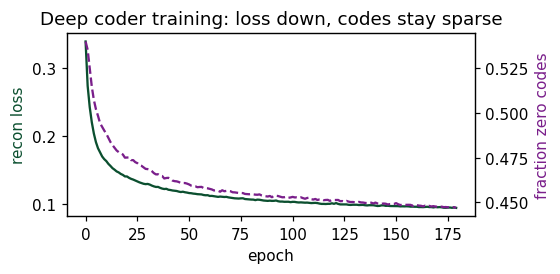

In [7]:
import torch
from separation.stage_d_scn import SparseNet, separate as scn_separate, device_auto

ckpt = torch.load(REPO / "experiments" / "sparsenet" / "model.pth",
                  map_location="cpu", weights_only=False)
model = SparseNet(**ckpt["config"]); model.load_state_dict(ckpt["state_dict"]); model.eval()
print(f"Loaded SparseNet: {ckpt['n_params']:,} parameters, context = {ckpt['config'].get('context',0)} frames")

res_D = scn_separate(y, model)
print(f"Deep coder  vocals SI-SDR: {si_sdr(voc, res_D['vocals']):+.2f} dB   "
      f"accomp. SI-SDR: {si_sdr(acc, res_D['accompaniment']):+.2f} dB")
display(Audio(res_D["vocals"], rate=SR))

# Training curve: loss falls while the internal codes stay sparse.
hist = np.load(REPO / "experiments" / "sparsenet" / "history.npy", allow_pickle=True)
ep = [h["epoch"] for h in hist]; loss = [h["loss"] for h in hist]; sp = [h["sparsity"] for h in hist]
fig, ax1 = plt.subplots(figsize=(5.2, 2.6))
ax1.plot(ep, loss, color="#0B4F2F"); ax1.set_xlabel("epoch"); ax1.set_ylabel("recon loss", color="#0B4F2F")
ax2 = ax1.twinx(); ax2.plot(ep, sp, "--", color="#7A1F8B"); ax2.set_ylabel("fraction zero codes", color="#7A1F8B")
ax1.set_title("Deep coder training: loss down, codes stay sparse"); plt.tight_layout(); plt.show()

## 6. The full comparison (25 held-out test tracks)

The cells above ran on one song. Here is the headline result over all 25 held-out
test tracks (median SI-SDR), loaded from the saved evaluation, together with the
trivial floors and the oracle ceilings. Read the table as a ladder: **training-free
< supervised < deep**, and the deep coder wins on both sources while being the
fastest learned model.

Method                   Vocals  Accomp.  Time(s)
-------------------------------------------------
HPSS (median)             -11.9     -1.4    0.274
REPET-SIM                  -0.7      2.9    0.078
Robust PCA                 -3.1      0.2    1.125
Supervised NMF              0.5      5.1    0.453
K-SVD + SRC                 0.8      7.1    0.269
Deep coder (ours)           2.0      8.3    0.118
Oracle IRM                 10.1     15.3    0.027


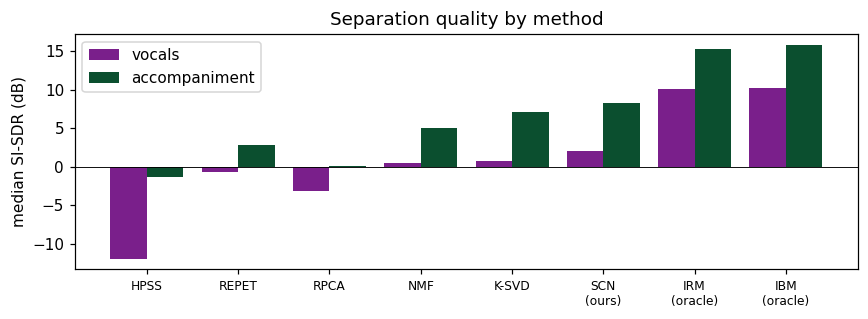

In [8]:
summary = json.load(open(REPO / "experiments" / "results" / "main_summary.json"))
order = [("mixture_floor","Mixture (no split)"), ("random","Random mask")]  # placeholders if present
rows = [("hpss","HPSS (median)"), ("repet","REPET-SIM"), ("rpca","Robust PCA"),
        ("nmf","Supervised NMF"), ("ksvd","K-SVD + SRC"), ("scn","Deep coder (ours)"),
        ("oracle_irm","Oracle IRM")]
print(f"{'Method':22s}{'Vocals':>9}{'Accomp.':>9}{'Time(s)':>9}")
print("-"*49)
for key, name in rows:
    s = summary.get(key, {})
    v = s.get("vocals_si_sdr_median"); a = s.get("acc_si_sdr_median"); t = s.get("time_mean_s","-")
    print(f"{name:22s}{v:>9.1f}{a:>9.1f}{str(t):>9}")

# Bar chart.
labels = {"hpss":"HPSS","repet":"REPET","rpca":"RPCA","nmf":"NMF","ksvd":"K-SVD",
          "scn":"SCN\\n(ours)","oracle_irm":"IRM\\n(oracle)","oracle_ibm":"IBM\\n(oracle)"}
keys = [k for k in ["hpss","repet","rpca","nmf","ksvd","scn","oracle_irm","oracle_ibm"] if k in summary]
voc = [summary[k]["vocals_si_sdr_median"] for k in keys]
acc = [summary[k]["acc_si_sdr_median"] for k in keys]
x = np.arange(len(keys)); w = 0.4
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(x - w/2, voc, w, label="vocals", color="#7A1F8B")
ax.bar(x + w/2, acc, w, label="accompaniment", color="#0B4F2F")
ax.axhline(0, color="k", lw=0.6); ax.set_xticks(x)
ax.set_xticklabels([labels[k].replace("\\n","\n") for k in keys], fontsize=8)
ax.set_ylabel("median SI-SDR (dB)"); ax.set_title("Separation quality by method")
ax.legend(); plt.tight_layout(); plt.show()

## 7. Ablations: what each knob does

One setting changed at a time. The interesting findings: **smaller NMF dictionaries
generalize better** (a small dictionary is a stronger prior when data is limited);
K-SVD improves with the sparsity budget up to $s\approx10$; and a larger RPCA
penalty $\lambda$ yields cleaner vocals.

In [9]:
import csv
def show_csv(name):
    rows = list(csv.DictReader(open(REPO / "experiments" / "results" / name)))
    return rows
for fn, knob in [("ablation_nmf.csv","NMF atoms K"), ("ablation_ksvd.csv","K-SVD sparsity s"),
                 ("ablation_rpca.csv","RPCA lambda scale")]:
    rows = show_csv(fn)
    xcol = list(rows[0].keys())[0]
    line = "  ".join(f"{r[xcol]}: {float(r['vocals_si_sdr']):+.1f}" for r in rows)
    print(f"{knob:20s} -> vocal SI-SDR   {line}")

NMF atoms K          -> vocal SI-SDR   16: +2.2  32: +1.9  64: +1.8  128: +1.5
K-SVD sparsity s     -> vocal SI-SDR   3: +1.4  5: +2.3  10: +2.7  15: +2.7
RPCA lambda scale    -> vocal SI-SDR   0.5: -3.9  1.0: -3.6  1.5: -3.2  2.0: -2.3


## 8. An honest negative result: dictionary coherence

The recovery theory promises exact recovery when the dictionary's coherence
$\mu = \max_{i\ne j}|\langle \mathbf{d}_i,\mathbf{d}_j\rangle|$ is small, specifically
for sparsity $s < \tfrac12(1 + 1/\mu)$. But a dictionary **trained for
reconstruction** ends up **coherent**: its atoms overlap. We measure $\mu$ on the
learned K-SVD vocal dictionary and find the worst-case theorem certifies almost
nothing, yet the method works at $s=10$. The guarantees are worst-case; real music
frames are far from that adversarial case.

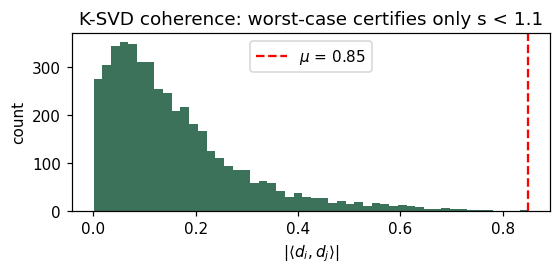

coherence mu = 0.850  ->  exact-recovery certified only for s < 1.1, but the method runs at s = 10 and works.


In [10]:
D = Dv_ksvd / (np.linalg.norm(Dv_ksvd, axis=0, keepdims=True) + 1e-9)
G = np.abs(D.T @ D); np.fill_diagonal(G, 0)
mu = G.max(); off = G[np.triu_indices_from(G, k=1)]
s_rec = 0.5 * (1 + 1/mu)
plt.figure(figsize=(5.2, 2.6))
plt.hist(off, bins=50, color="#0B4F2F", alpha=0.8)
plt.axvline(mu, color="red", ls="--", label=f"$\\mu$ = {mu:.2f}")
plt.title(f"K-SVD coherence: worst-case certifies only s < {s_rec:.1f}")
plt.xlabel(r"$|\langle d_i, d_j\rangle|$"); plt.ylabel("count"); plt.legend()
plt.tight_layout(); plt.show()
print(f"coherence mu = {mu:.3f}  ->  exact-recovery certified only for s < {s_rec:.1f},"
      f" but the method runs at s = 10 and works.")

## 9. Conclusion

On one STFT front end, four methods that look different, a low-rank-plus-sparse
split, two learned dictionaries, and an unrolled deep solver, are one family. The
amount of structure learned from data climbs left to right, and quality climbs with
it: the deep sparse coding network is the strongest non-oracle separator on both
sources (**2.0 dB vocals, 8.3 dB accompaniment**) and the fastest learned model. The
classical recovery theory is a guide rather than a guarantee for trained, coherent
dictionaries.

Everything here, the five-page report, the poster, the trained models, and curated
audio, is in the repository:
<https://github.com/takakhoo/ENGS109_Final_Project>.